In [9]:
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics

df = pd.read_csv(r"C:\Users\D\codes\health_data.csv")

In [20]:
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
cols_to_int = ['id','age','height','ap_hi','ap_lo']
df[cols_to_int] = df[cols_to_int].round().astype('int64')

In [14]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [21]:
df=df.drop(df.columns[0],axis=1)

In [22]:
df1 = df.copy()
df1["age"] = (df1["age"] / 365).astype(int)
df1 = df1[(df1['ap_hi'] >= 70) & (df1['ap_hi'] <= 250) &
        (df1['ap_lo'] >= 40) & (df1['ap_lo'] <= 150) &
        (df1['height'] > 120) & (df1['height'] < 250)]

df1["BMI"] = df1["weight"] / ((df1["height"]/100) ** 2)
df1

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50,1,168,62.0,110,80,0,0,0,0,1,0,21.967120
1,55,0,156,85.0,140,90,2,0,0,0,1,1,34.927679
2,51,0,165,64.0,130,70,2,0,0,0,0,1,23.507805
3,48,1,169,82.0,150,100,0,0,0,0,1,1,28.710479
4,47,0,156,56.0,100,60,0,0,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,1,0,26.927438
69996,61,0,158,126.0,140,90,1,1,0,0,1,1,50.472681
69997,52,1,183,105.0,180,90,2,0,0,1,0,1,31.353579
69998,61,0,163,72.0,135,80,0,1,0,0,0,1,27.099251


In [23]:
df2 = df1[(df1['BMI'] >= 10.0)]
df2

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50,1,168,62.0,110,80,0,0,0,0,1,0,21.967120
1,55,0,156,85.0,140,90,2,0,0,0,1,1,34.927679
2,51,0,165,64.0,130,70,2,0,0,0,0,1,23.507805
3,48,1,169,82.0,150,100,0,0,0,0,1,1,28.710479
4,47,0,156,56.0,100,60,0,0,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,1,0,26.927438
69996,61,0,158,126.0,140,90,1,1,0,0,1,1,50.472681
69997,52,1,183,105.0,180,90,2,0,0,1,0,1,31.353579
69998,61,0,163,72.0,135,80,0,1,0,0,0,1,27.099251


In [24]:
df2 = df2.copy()
df2


# PP = ap_hi - ap_lo


# df1['PP'] = df1['ap_hi'] - df1['ap_lo'] # Pulse Pressuere (30->50)
# df1['MAP'] = df1['ap_lo'] + ((df1['ap_hi'] - df1['ap_lo']) / 3) ()
# display(df1.head()) 

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI
0,50,1,168,62.0,110,80,0,0,0,0,1,0,21.967120
1,55,0,156,85.0,140,90,2,0,0,0,1,1,34.927679
2,51,0,165,64.0,130,70,2,0,0,0,0,1,23.507805
3,48,1,169,82.0,150,100,0,0,0,0,1,1,28.710479
4,47,0,156,56.0,100,60,0,0,0,0,0,0,23.011177
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,1,0,26.927438
69996,61,0,158,126.0,140,90,1,1,0,0,1,1,50.472681
69997,52,1,183,105.0,180,90,2,0,0,1,0,1,31.353579
69998,61,0,163,72.0,135,80,0,1,0,0,0,1,27.099251


In [25]:
# 0 -> Low 
# 1 -> Normal 
# 2 -> High 

def blood_pressure_status(row):
    if row['ap_hi'] < 90 or row['ap_lo'] < 60:
        return 0
    elif 90 <= row['ap_hi'] <= 120 and 60 <= row['ap_lo'] <= 80:
        return 1
    elif (120 < row['ap_hi'] < 140) or (80 < row['ap_lo'] < 90):
        return 1
    elif row['ap_hi'] >= 140 or row['ap_lo'] >= 90:
        return 2
    else:
        return 'Unknown'

df2['bp_status'] = df2.apply(blood_pressure_status,axis=1)
df2

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,bp_status
0,50,1,168,62.0,110,80,0,0,0,0,1,0,21.967120,1
1,55,0,156,85.0,140,90,2,0,0,0,1,1,34.927679,2
2,51,0,165,64.0,130,70,2,0,0,0,0,1,23.507805,1
3,48,1,169,82.0,150,100,0,0,0,0,1,1,28.710479,2
4,47,0,156,56.0,100,60,0,0,0,0,0,0,23.011177,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,1,0,26.927438,1
69996,61,0,158,126.0,140,90,1,1,0,0,1,1,50.472681,2
69997,52,1,183,105.0,180,90,2,0,0,1,0,1,31.353579,2
69998,61,0,163,72.0,135,80,0,1,0,0,0,1,27.099251,1


In [26]:
 df2



,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,BMI,bp_status
0,50,1,168,62.0,110,80,0,0,0,0,1,0,21.967120,1
1,55,0,156,85.0,140,90,2,0,0,0,1,1,34.927679,2
2,51,0,165,64.0,130,70,2,0,0,0,0,1,23.507805,1
3,48,1,169,82.0,150,100,0,0,0,0,1,1,28.710479,2
4,47,0,156,56.0,100,60,0,0,0,0,0,0,23.011177,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,52,1,168,76.0,120,80,0,0,1,0,1,0,26.927438,1
69996,61,0,158,126.0,140,90,1,1,0,0,1,1,50.472681,2
69997,52,1,183,105.0,180,90,2,0,0,1,0,1,31.353579,2
69998,61,0,163,72.0,135,80,0,1,0,0,0,1,27.099251,1


In [27]:
df3 = df2.drop(columns=['height', 'weight', 'ap_hi', 'ap_lo'])
df3

,age,gender,cholesterol,gluc,smoke,alco,active,cardio,BMI,bp_status
0,50,1,0,0,0,0,1,0,21.967120,1
1,55,0,2,0,0,0,1,1,34.927679,2
2,51,0,2,0,0,0,0,1,23.507805,1
3,48,1,0,0,0,0,1,1,28.710479,2
4,47,0,0,0,0,0,0,0,23.011177,1
...,...,...,...,...,...,...,...,...,...,...
69995,52,1,0,0,1,0,1,0,26.927438,1
69996,61,0,1,1,0,0,1,1,50.472681,2
69997,52,1,2,0,0,1,0,1,31.353579,2
69998,61,0,0,1,0,0,0,1,27.099251,1


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
# Convert all categorical features to numeric if not already
df_corr = df3.copy()
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bp_status']
for col in categorical_cols:
    df_corr[col] = pd.Categorical(df_corr[col]).codes  # encode categories as integers

# Compute correlation with target 'cardio'
correlation = df_corr.corr()['cardio'].sort_values(ascending=False)
correlation
# plt.figure(figsize=(10,6))
# sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
# plt.show()

cardio         1.000000
bp_status      0.392136
age            0.239373
cholesterol    0.221523
BMI            0.191074
gluc           0.089960
gender         0.007170
alco          -0.008341
smoke         -0.016215
active        -0.037329
Name: cardio, dtype: float64

cardio         1.000000
bp_status      0.392136
age            0.239373
cholesterol    0.221523
BMI            0.191074
gluc           0.089960
gender         0.007170
alco          -0.008341
smoke         -0.016215
active        -0.037329
Name: cardio, dtype: float64


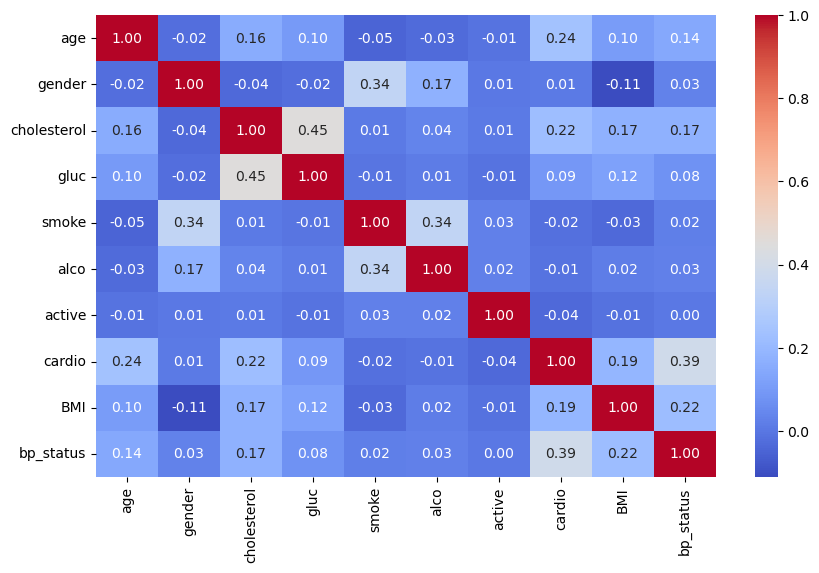

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert all categorical features to numeric if not already
df_corr = df3.copy()

categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 
                    'alco', 'active', 'bp_status']

for col in categorical_cols:
    df_corr[col] = pd.Categorical(df_corr[col]).codes  # encode categories as integers

# Compute correlation with target 'cardio'
correlation = df_corr.corr()['cardio'].sort_values(ascending=False)
print(correlation)

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

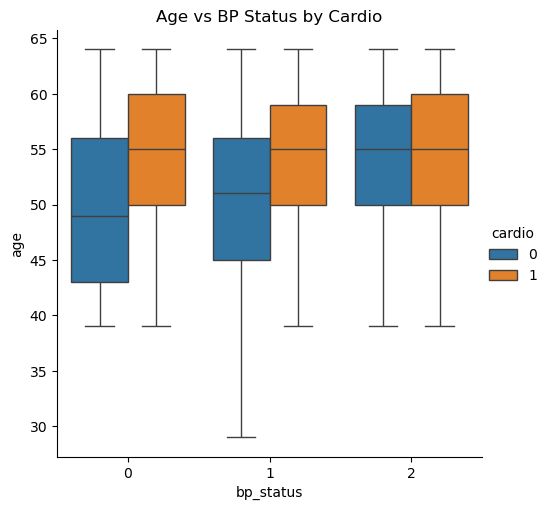

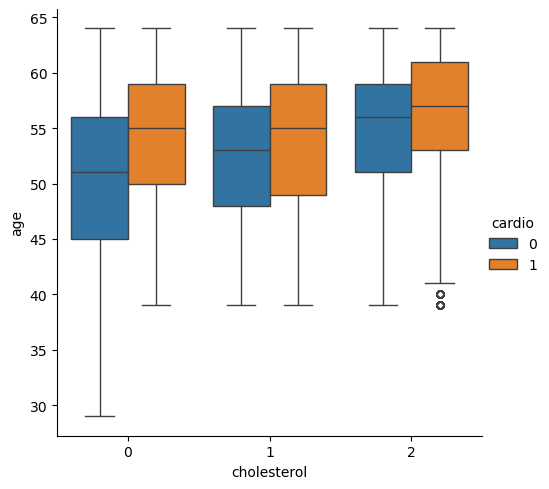

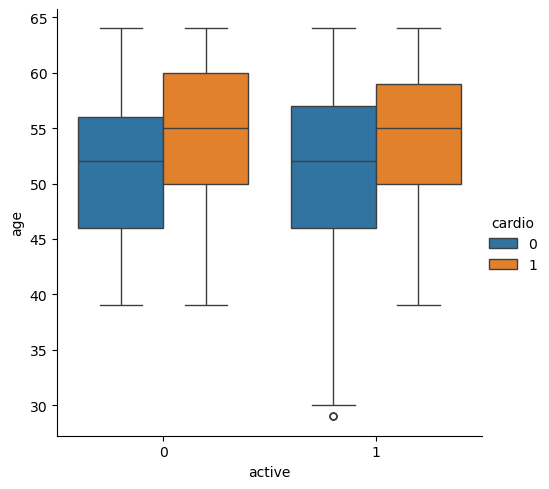

In [30]:
# Age vs. bp_status, colored by cardio
sns.catplot(data=df3, x='bp_status', y='age', hue='cardio', kind='box')
plt.title('Age vs BP Status by Cardio')
plt.show()

# Cholesterol vs bp_status
sns.catplot(data=df3, x='cholesterol', y='age', hue='cardio', kind='box')
plt.show()

# Active vs Age
sns.catplot(data=df3, x='active', y='age', hue='cardio', kind='box')
plt.show()

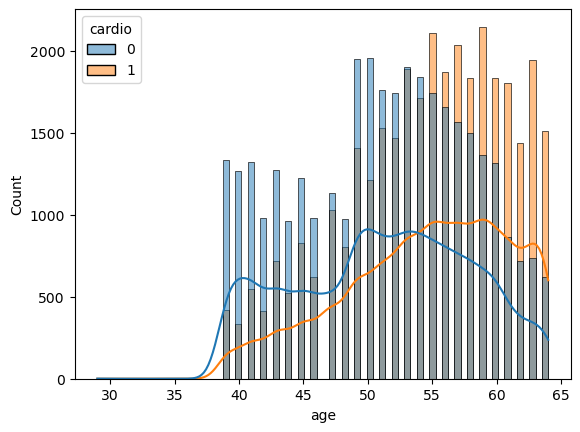

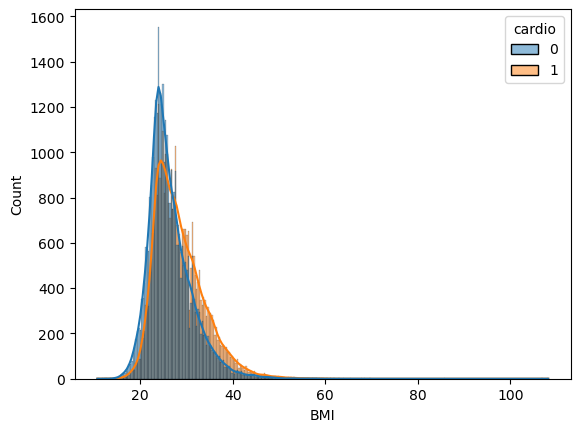

In [31]:
# Age distribution
sns.histplot(data=df3, x='age', hue='cardio', kde=True)
plt.show()

# BMI distribution
sns.histplot(data=df3, x='BMI', hue='cardio', kde=True)
plt.show()




C:\Users\D\AppData\Local\Temp\ipykernel_21488\88965501.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_active_cardio = df3.groupby(['age_bin', 'active'])['cardio'].mean().reset_index()


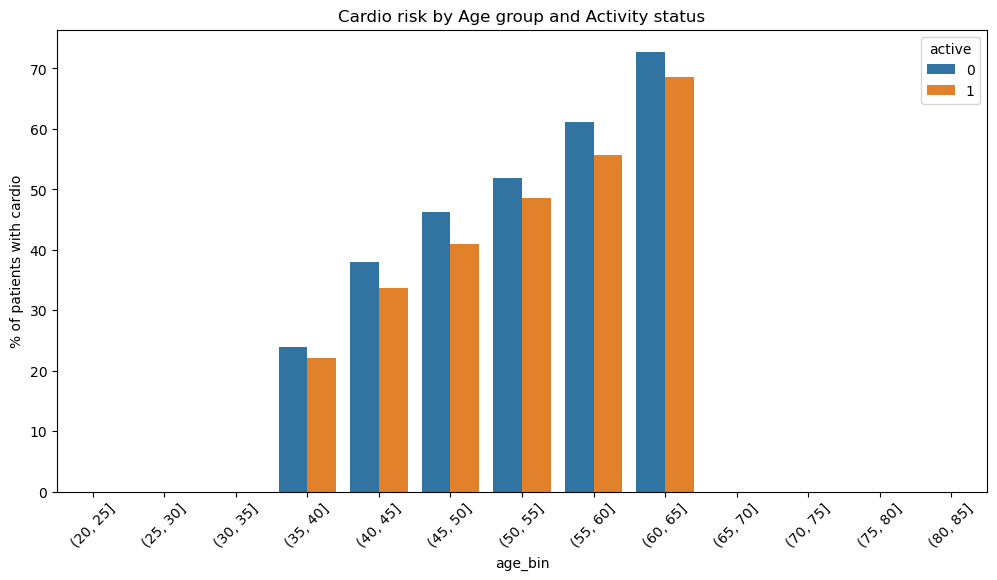

In [32]:

df3['age_bin'] = pd.cut(df3['age'], bins=range(20, 90, 5))

# Calculate % of cardio=1 per age_bin and active
age_active_cardio = df3.groupby(['age_bin', 'active'])['cardio'].mean().reset_index()
age_active_cardio['cardio_percent'] = age_active_cardio['cardio'] * 100


plt.figure(figsize=(12,6))
sns.barplot(data=age_active_cardio, x='age_bin', y='cardio_percent', hue='active')
plt.xticks(rotation=45)
plt.ylabel('% of patients with cardio')
plt.title('Cardio risk by Age group and Activity status')
plt.show()

In [37]:
df_final = df3.copy()
df_final.drop("age_bin",inplace=True,axis=1)
df_final

,age,gender,cholesterol,gluc,smoke,alco,active,cardio,BMI,bp_status
0,50,1,0,0,0,0,1,0,21.967120,1
1,55,0,2,0,0,0,1,1,34.927679,2
2,51,0,2,0,0,0,0,1,23.507805,1
3,48,1,0,0,0,0,1,1,28.710479,2
4,47,0,0,0,0,0,0,0,23.011177,1
...,...,...,...,...,...,...,...,...,...,...
69995,52,1,0,0,1,0,1,0,26.927438,1
69996,61,0,1,1,0,0,1,1,50.472681,2
69997,52,1,2,0,0,1,0,1,31.353579,2
69998,61,0,0,1,0,0,0,1,27.099251,1


In [36]:
# 1️⃣ Libraries
!pip install lightgbm
import lightgbm as lgb
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
df_final.to_csv(r"C:\Users\D\codes\health_data.csv")

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   --------------------- ------------------ 0.8/1.5 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.8 MB/s  0:00:00


[LightGBM] [Info] Number of positive: 27182, number of negative: 27750
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001858 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 306
[LightGBM] [Info] Number of data points in the train set: 54932, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.595026 -> initscore=0.384784
[LightGBM] [Info] Start training from score 0.384784
Accuracy: 0.6615698267074414
ROC-AUC: 0.781957259632996
              precision    recall  f1-score   support

           0       0.78      0.46      0.58      6938
           1       0.61      0.87      0.72      6796

    accuracy                           0.66     13734
   macro avg       0.70      0.66      0.65     13734
weighted avg       0.70      0.66      0.65     13734



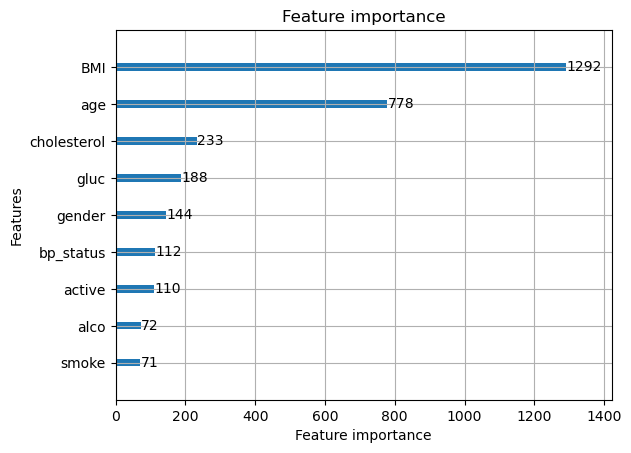

In [39]:
# 3️⃣ Prepare features and target
X = df_final.drop(columns=['id', 'cardio'], errors='ignore')
y = df_final['cardio']

# 4️⃣ Convert categorical/binary columns for LightGBM
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bp_status']
for col in categorical_cols:
    X[col] = X[col].astype('category')

# 5️⃣ Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6️⃣ Train LightGBM classifier
model = lgb.LGBMClassifier(random_state=42, class_weight={0:1, 1:1.5})
model.fit(X_train, y_train, categorical_feature=categorical_cols)

# 7️⃣ Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]
threshold = 0.4  # lower threshold to increase recall
y_pred_new = (y_prob >= threshold).astype(int)


# 8️⃣ Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_new))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred_new))

# 9️⃣ Feature importance
lgb.plot_importance(model, max_num_features=10)
plt.show()


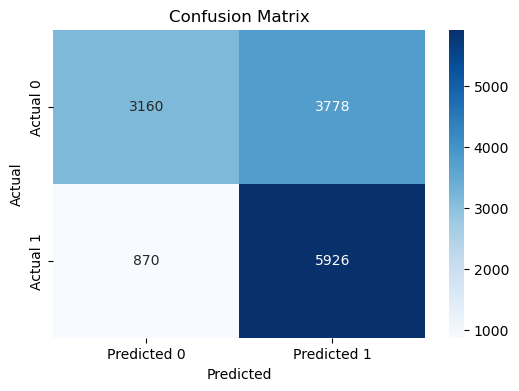

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_new)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
# 1️⃣ Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

X = df_final.drop(columns=['id', 'cardio'], errors='ignore')
y = df_final['cardio']


# 3️⃣ Encode categorical variables (one-hot)
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bp_status']
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 4️⃣ Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5️⃣ Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)

# 6️⃣ Train SVM
svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)  # kernel can be 'linear', 'rbf', etc.
svm_model.fit(X_train, y_train)

# 7️⃣ Predictions
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:,1]

# 8️⃣ Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('SVM Confusion Matrix')
plt.show()
